# Exploratory analysis — RQ9, RQ9 extension and RQ12

This notebook investigates three questions:

1. **RQ9:** Does a larger inundation extent necessarily correspond to greater population and livelihood exposure?
2. **RQ9 extension:** Does larger inundation correspond to greater population and infrastructure exposure?
3. **RQ12:** Which healthcare facilities and population areas are most frequently exposed to historical flooding?

## Scope and limitations

The available local data contains MODIS/VIIRS flood detections and one WorldPop raster for 2015. Therefore, the empirical analysis quantifies **inundation extent**, **estimated population exposure**, and **frequently flooded populated locations**. Population in every historical year is evaluated using the same 2015 population surface, so the results describe historical flooding projected onto the 2015 population distribution.

Livelihood, infrastructure and healthcare-facility exposure cannot be quantified because their spatial datasets are not present in the supplied `raw_data` folder. The notebook reports these parts as unavailable rather than treating missing information as zero exposure.

Flood-mask rows represent centres of approximately 232 m cells. Population exposure is approximated by sampling population density at each flooded cell centre and scaling it to the flood-cell area. Results should therefore be interpreted as exploratory estimates rather than exact affected-person counts.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from scipy.stats import spearmanr
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

# Make execution independent of whether PyCharm starts in the project root or notebooks/.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

candidate_roots = [
    PROJECT_ROOT / "raw_data" / "data-JBG060-2026",
    PROJECT_ROOT / "raw_data",
]
DATA_ROOT = next((p for p in candidate_roots if (p / "flood_masks").exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find flood_masks. Expected raw_data/data-JBG060-2026/flood_masks "
        "or raw_data/flood_masks."
    )

FLOOD_ROOT = DATA_ROOT / "flood_masks"
POP_FILE = DATA_ROOT / "worldpop" / "ssd_pop_2015_CN_100m_R2025A_v1.tif"
if not POP_FILE.exists():
    raise FileNotFoundError(f"Population raster not found: {POP_FILE}")

OUTPUT_DIR = PROJECT_ROOT / "results" / "rq9_rq12"
PROCESSED_DIR = PROJECT_ROOT / "processed_data" / "rq9_rq12"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data root:   ", DATA_ROOT)
print("Output dir:  ", OUTPUT_DIR)
print("Flood files: ", len(list(FLOOD_ROOT.glob("compact_*/*.parquet"))))
print("Population:  ", POP_FILE.name)

Project root: /Users/babiepp/PycharmProjects/JBG060_ZHL_2026
Data root:    /Users/babiepp/PycharmProjects/JBG060_ZHL_2026/raw_data/data-JBG060-2026
Output dir:   /Users/babiepp/PycharmProjects/JBG060_ZHL_2026/results/rq9_rq12
Flood files:  104
Population:   ssd_pop_2015_CN_100m_R2025A_v1.tif


## 1. Process flood detections and estimate population exposure

For each date, inundation extent is calculated by summing the approximate area of unique flooded MODIS/VIIRS cells. Population exposure is estimated from the 2015 WorldPop raster at the same locations. Recurring and unusual records at the same date and coordinate are counted only once.

In [3]:
FLOOD_STEP_DEG = 0.0020833  # documented flood-grid spacing, approximately 232 m

def flood_cell_area_km2(latitudes):
    # Approximate area of a flood grid cell at each latitude.
    latitudes = np.asarray(latitudes, dtype=float)
    north_south_km = 110.574 * FLOOD_STEP_DEG
    east_west_km = 111.320 * np.cos(np.deg2rad(latitudes)) * FLOOD_STEP_DEG
    return north_south_km * east_west_km


def population_exposure_at_points(src, population_array, lon, lat, flood_area):
    # Estimate people inside flood cells from local WorldPop density.
    lon = np.asarray(lon)
    lat = np.asarray(lat)
    rows, cols = rasterio.transform.rowcol(src.transform, lon, lat)
    rows = np.asarray(rows)
    cols = np.asarray(cols)
    valid = (
        (rows >= 0) & (rows < src.height) &
        (cols >= 0) & (cols < src.width)
    )
    sampled = np.zeros(len(lon), dtype=np.float64)
    sampled[valid] = population_array[rows[valid], cols[valid]]
    if src.nodata is not None:
        sampled[sampled == src.nodata] = 0
    sampled[~np.isfinite(sampled)] = 0
    sampled[sampled < 0] = 0

    # WorldPop values are people per raster cell. Convert to local people/km²,
    # then multiply by the approximate MODIS/VIIRS flood-cell area.
    pop_width_deg = abs(src.transform.a)
    pop_height_deg = abs(src.transform.e)
    pop_area_km2 = (
        (110.574 * pop_height_deg) *
        (111.320 * np.cos(np.deg2rad(lat)) * pop_width_deg)
    )
    density = np.divide(sampled, pop_area_km2, out=np.zeros_like(sampled), where=pop_area_km2 > 0)
    return density * flood_area


def build_exposure_tables(force_recompute=False):
    daily_cache = PROCESSED_DIR / "daily_exposure.csv"
    hotspot_cache = PROCESSED_DIR / "populated_flood_hotspots.parquet"
    if not force_recompute and daily_cache.exists() and hotspot_cache.exists():
        print("Loading cached results. Set force_recompute=True after changing raw data.")
        daily = pd.read_csv(daily_cache, parse_dates=["date"])
        hotspots = pd.read_parquet(hotspot_cache)
        return daily, hotspots

    daily_parts = []
    populated_location_parts = []
    years = sorted({int(p.stem.rsplit("_", 1)[-1]) for p in FLOOD_ROOT.glob("compact_*/*.parquet")})
    tiles = ["h20v08", "h21v08"]

    with rasterio.open(POP_FILE) as pop_src:
        pop_array = pop_src.read(1)

        for year in years:
            print(f"Processing {year}...")
            for tile in tiles:
                frames = []
                for flood_type in ["recurring", "unusual"]:
                    path = FLOOD_ROOT / f"compact_{flood_type}" / f"flood_events_{tile}_{year}.parquet"
                    if path.exists():
                        frame = pd.read_parquet(path, columns=["date", "lat", "lon"])
                        frame["flood_type"] = flood_type
                        frames.append(frame)
                if not frames:
                    continue

                chunk = pd.concat(frames, ignore_index=True)
                chunk["date"] = pd.to_datetime(chunk["date"].astype(str), errors="coerce")
                chunk = chunk.dropna(subset=["date"])
                # If both types identify the same cell/date, unusual takes priority.
                chunk["type_priority"] = (chunk["flood_type"] == "unusual").astype(int)
                chunk = (
                    chunk.sort_values("type_priority", ascending=False)
                    .drop_duplicates(["date", "lat", "lon"])
                )

                chunk["area_km2"] = flood_cell_area_km2(chunk["lat"])
                chunk["population_exposed_est"] = population_exposure_at_points(
                    pop_src,
                    pop_array,
                    chunk["lon"].to_numpy(),
                    chunk["lat"].to_numpy(),
                    chunk["area_km2"].to_numpy(),
                )

                daily_part = chunk.groupby("date", as_index=False).agg(
                    inundation_km2=("area_km2", "sum"),
                    population_exposed_est=("population_exposed_est", "sum"),
                    flooded_cells=("lat", "size"),
                    unusual_cells=("type_priority", "sum"),
                )
                daily_parts.append(daily_part)

                populated = chunk.loc[
                    chunk["population_exposed_est"] > 0,
                    ["date", "lat", "lon", "population_exposed_est"],
                ].drop_duplicates(["date", "lat", "lon"])
                if not populated.empty:
                    loc = populated.groupby(["lat", "lon"], as_index=False).agg(
                        flooded_days=("date", "nunique"),
                        first_flood=("date", "min"),
                        last_flood=("date", "max"),
                        population_2015_est=("population_exposed_est", "max"),
                    )
                    populated_location_parts.append(loc)

    daily = (
        pd.concat(daily_parts, ignore_index=True)
        .groupby("date", as_index=False)
        .agg({
            "inundation_km2": "sum",
            "population_exposed_est": "sum",
            "flooded_cells": "sum",
            "unusual_cells": "sum",
        })
        .sort_values("date")
    )
    daily["year"] = daily["date"].dt.year
    daily["month"] = daily["date"].dt.month

    hotspots = (
        pd.concat(populated_location_parts, ignore_index=True)
        .groupby(["lat", "lon"], as_index=False)
        .agg(
            flooded_days=("flooded_days", "sum"),
            first_flood=("first_flood", "min"),
            last_flood=("last_flood", "max"),
            population_2015_est=("population_2015_est", "max"),
        )
        .sort_values(["flooded_days", "population_2015_est"], ascending=False)
    )

    daily.to_csv(daily_cache, index=False)
    hotspots.to_parquet(hotspot_cache, index=False)
    print(f"Saved {daily_cache.relative_to(PROJECT_ROOT)}")
    print(f"Saved {hotspot_cache.relative_to(PROJECT_ROOT)}")
    return daily, hotspots


daily, hotspots = build_exposure_tables(force_recompute=False)
display(daily.head())
print(f"Analysed {len(daily):,} dates with detected flooding.")
print(f"Found {len(hotspots):,} populated flood-grid locations.")

Processing 2000...
Processing 2001...
Processing 2002...
Processing 2003...
Processing 2004...
Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
Processing 2025...
Saved processed_data/rq9_rq12/daily_exposure.csv
Saved processed_data/rq9_rq12/populated_flood_hotspots.parquet


,date,inundation_km2,population_exposed_est,flooded_cells,unusual_cells,year,month
0,2000-02-28,39.779099,0.0,753,672,2000,2
1,2000-02-29,28.973527,0.0,549,528,2000,2
2,2000-03-01,9.393997,0.0,178,86,2000,3
3,2000-03-02,10.101567,0.0,191,77,2000,3
4,2000-03-03,14.938689,0.0,281,104,2000,3


Analysed 9,242 dates with detected flooding.
Found 38,954 populated flood-grid locations.


## 2. RQ9 — inundation extent versus population and livelihood exposure

Spearman's rank correlation is used because flood extent and exposure are expected to be skewed and the relationship does not need to be linear. A positive correlation indicates that larger floods generally expose more people, but it does not imply that every larger flood has greater exposure.

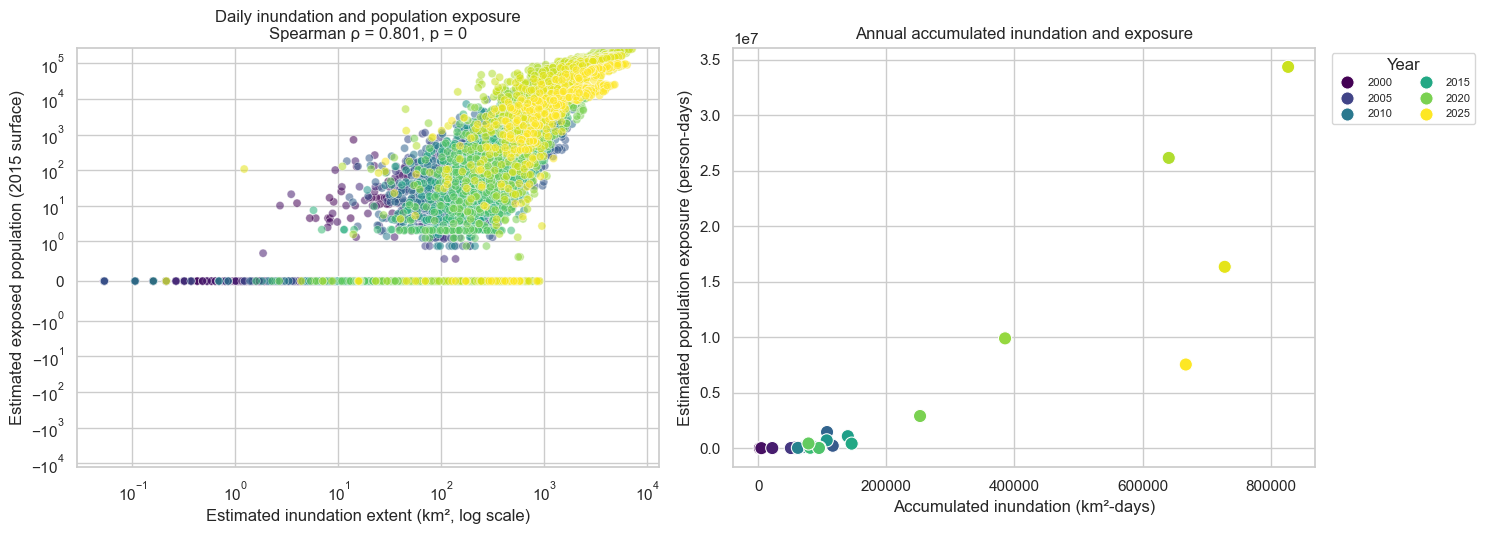

Spearman correlation: rho=0.8011, p=0


,year,inundation_km2,population_exposed_est,flood_days
23,2023,827253.489173,3.437852e+07,362
22,2022,640912.772334,2.617199e+07,363
24,2024,728265.709806,1.635309e+07,365
21,2021,385304.153261,9.900864e+06,362
25,2025,667492.041816,7.541717e+06,357
20,2020,252590.009914,2.899947e+06,364
8,2008,107367.270755,1.453233e+06,366
14,2014,139797.907667,1.080540e+06,360
13,2013,106902.528362,7.055035e+05,359
19,2019,78393.245090,4.220905e+05,364


In [4]:
valid = daily.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["inundation_km2", "population_exposed_est"]
)
rho, p_value = spearmanr(valid["inundation_km2"], valid["population_exposed_est"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(
    data=valid,
    x="inundation_km2",
    y="population_exposed_est",
    hue="year",
    palette="viridis",
    alpha=0.55,
    s=35,
    legend=False,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set_title(f"Daily inundation and population exposure\nSpearman ρ = {rho:.3f}, p = {p_value:.3g}")
axes[0].set_xlabel("Estimated inundation extent (km², log scale)")
axes[0].set_ylabel("Estimated exposed population (2015 surface)")

yearly = valid.groupby("year", as_index=False).agg(
    inundation_km2=("inundation_km2", "sum"),
    population_exposed_est=("population_exposed_est", "sum"),
    flood_days=("date", "nunique"),
)
sns.scatterplot(
    data=yearly,
    x="inundation_km2",
    y="population_exposed_est",
    hue="year",
    palette="viridis",
    s=90,
    ax=axes[1],
)
axes[1].set_title("Annual accumulated inundation and exposure")
axes[1].set_xlabel("Accumulated inundation (km²-days)")
axes[1].set_ylabel("Estimated population exposure (person-days)")
axes[1].legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2, fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "rq9_inundation_vs_population.png", dpi=220, bbox_inches="tight")
plt.show()

print(f"Spearman correlation: rho={rho:.4f}, p={p_value:.4g}")
display(yearly.sort_values("population_exposed_est", ascending=False).head(10))

### Counterexamples to “larger flood means greater exposure”

Exposure density is the estimated exposed population divided by inundation extent. Days with high density are relatively small floods concentrated around populated locations; days with low density are floods concentrated in sparsely populated locations.

In [ ]:
comparison = valid.copy()
comparison["people_per_flooded_km2"] = np.divide(
    comparison["population_exposed_est"],
    comparison["inundation_km2"],
    out=np.zeros(len(comparison)),
    where=comparison["inundation_km2"] > 0,
)

largest = comparison.nlargest(10, "inundation_km2")[
    ["date", "inundation_km2", "population_exposed_est", "people_per_flooded_km2"]
]
most_concentrated = comparison.nlargest(10, "people_per_flooded_km2")[
    ["date", "inundation_km2", "population_exposed_est", "people_per_flooded_km2"]
]

display(Markdown("#### Ten largest daily inundations"))
display(largest)
display(Markdown("#### Ten floods with the highest population exposure per flooded km²"))
display(most_concentrated)

fig, ax = plt.subplots(figsize=(11, 5.5))
top_days = comparison.nlargest(15, "population_exposed_est").sort_values("population_exposed_est")
ax.barh(top_days["date"].dt.strftime("%Y-%m-%d"), top_days["population_exposed_est"], color="#d95f02")
ax.set_title("Flood dates with the greatest estimated population exposure")
ax.set_xlabel("Estimated exposed population (2015 surface)")
ax.set_ylabel("Flood date")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "rq9_highest_population_exposure_days.png", dpi=220, bbox_inches="tight")
plt.show()

## 3. RQ9 extension — population and infrastructure exposure

The population component is quantified above. Infrastructure exposure cannot be calculated from the supplied local files because no road network, buildings, or facility-location layer is present. Missing infrastructure data must not be interpreted as zero infrastructure exposure.

The inundation–population plot provides partial evidence for this extension, but a complete answer would require intersecting each flood footprint with infrastructure geometries and measuring, for example, exposed road kilometres or affected facilities.

,Exposure dimension,Available in supplied raw_data,Empirically quantified
0,Population,True,True
1,Livelihoods,False,False
2,Road infrastructure,False,False
3,Healthcare facilities,False,False


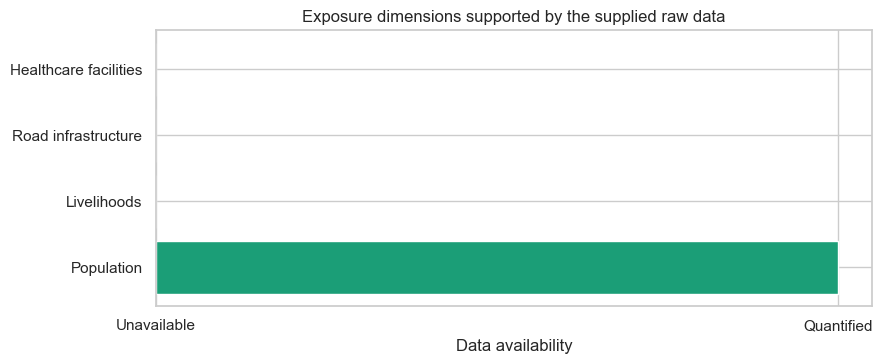

In [5]:
availability = pd.DataFrame({
    "Exposure dimension": ["Population", "Livelihoods", "Road infrastructure", "Healthcare facilities"],
    "Available in supplied raw_data": [True, False, False, False],
    "Empirically quantified": [True, False, False, False],
})
display(availability)

fig, ax = plt.subplots(figsize=(9, 3.8))
colors = availability["Empirically quantified"].map({True: "#1b9e77", False: "#bdbdbd"})
ax.barh(availability["Exposure dimension"], availability["Empirically quantified"].astype(int), color=colors)
ax.set_xlim(0, 1.05)
ax.set_xticks([0, 1], ["Unavailable", "Quantified"])
ax.set_title("Exposure dimensions supported by the supplied raw data")
ax.set_xlabel("Data availability")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "rq9_extension_data_availability.png", dpi=220, bbox_inches="tight")
plt.show()

## 4. RQ12 — most frequently exposed population areas

The table and map below rank populated flood-grid locations by the number of distinct dates on which flooding was detected. Coordinates are reported because administrative-boundary data is not available. Exact healthcare facilities cannot be ranked without their location dataset.

,lat,lon,flooded_days,first_flood,last_flood,population_2015_est
0,8.696875,29.294792,1077,2002-02-06,2023-02-28,6.893622
1,7.926042,30.655209,990,2003-12-13,2025-12-20,2.032516
2,9.115625,29.646875,898,2014-09-01,2025-03-31,18.998662
3,8.728125,29.182291,891,2002-11-03,2025-12-28,8.680654
4,9.144792,29.651041,862,2021-08-26,2025-03-31,21.373498
5,9.140625,29.651041,859,2021-08-24,2025-03-31,93.499149
6,9.146875,29.651041,856,2021-08-26,2025-03-31,97.936699
7,9.138541,29.655209,854,2021-08-24,2025-03-31,99.776254
8,9.138541,29.653126,854,2021-08-24,2025-03-31,1.583224
9,9.140625,29.655209,853,2021-08-24,2025-03-31,29.289601


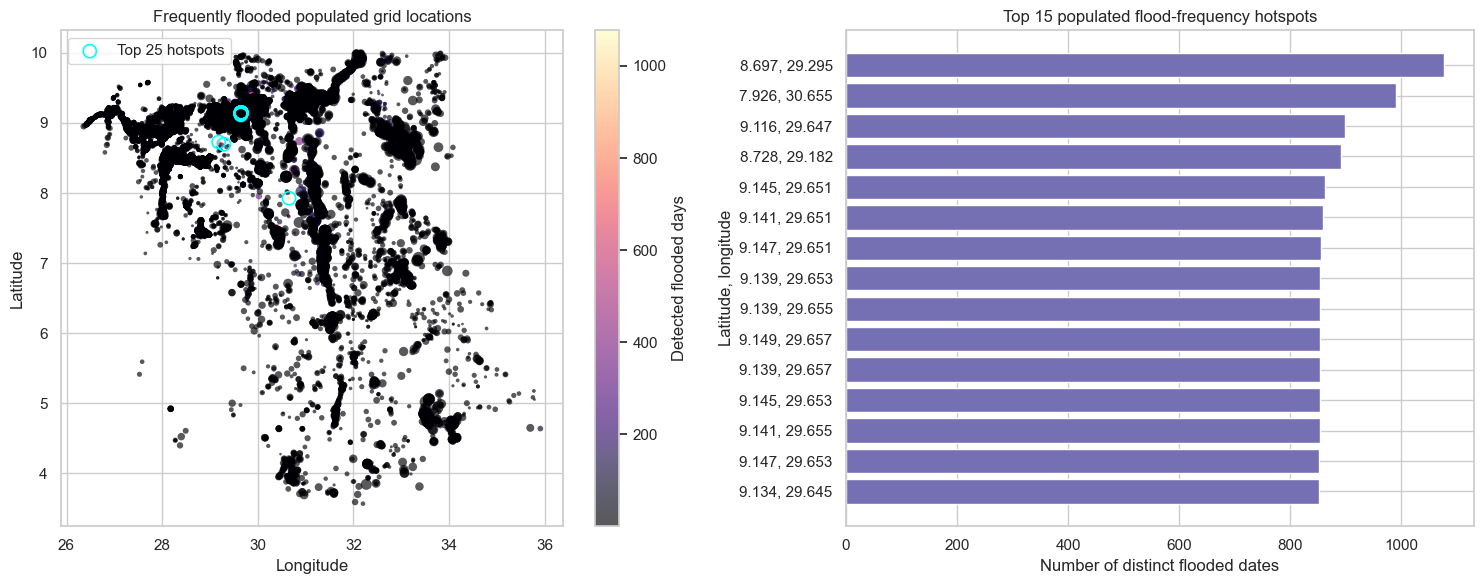

Saved figures and hotspot table to: /Users/babiepp/PycharmProjects/JBG060_ZHL_2026/results/rq9_rq12


In [6]:
top_hotspots = hotspots.head(25).copy()
display(top_hotspots.reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_sample = hotspots.copy()
if len(plot_sample) > 100_000:
    plot_sample = plot_sample.nlargest(100_000, "flooded_days")

points = axes[0].scatter(
    plot_sample["lon"],
    plot_sample["lat"],
    c=plot_sample["flooded_days"],
    s=np.clip(np.sqrt(plot_sample["population_2015_est"]) * 4, 3, 80),
    cmap="magma",
    alpha=0.65,
    linewidths=0,
)
axes[0].scatter(
    top_hotspots["lon"], top_hotspots["lat"],
    facecolors="none", edgecolors="cyan", s=90, linewidths=1.2,
    label="Top 25 hotspots",
)
axes[0].set_title("Frequently flooded populated grid locations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend(loc="best")
fig.colorbar(points, ax=axes[0], label="Detected flooded days")

ranked = top_hotspots.head(15).sort_values("flooded_days")
labels = [f"{lat:.3f}, {lon:.3f}" for lat, lon in zip(ranked["lat"], ranked["lon"])]
axes[1].barh(labels, ranked["flooded_days"], color="#7570b3")
axes[1].set_title("Top 15 populated flood-frequency hotspots")
axes[1].set_xlabel("Number of distinct flooded dates")
axes[1].set_ylabel("Latitude, longitude")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "rq12_population_hotspots.png", dpi=220, bbox_inches="tight")
plt.show()

top_hotspots.to_csv(OUTPUT_DIR / "rq12_top25_population_hotspots.csv", index=False)
print("Saved figures and hotspot table to:", OUTPUT_DIR)

## 5. Automatically generated conclusions

Run this cell after all previous cells. It converts the calculated results into concise text that can be used as a starting point for the report. Review the wording together with the plots before submission.

In [7]:
if abs(rho) < 0.2:
    strength = "very weak"
elif abs(rho) < 0.4:
    strength = "weak"
elif abs(rho) < 0.6:
    strength = "moderate"
elif abs(rho) < 0.8:
    strength = "strong"
else:
    strength = "very strong"

direction = "positive" if rho > 0 else "negative"
significance = "statistically significant" if p_value < 0.05 else "not statistically significant"
top = hotspots.iloc[0]

conclusion = f''' 
### RQ9

Across {len(valid):,} dates with detected flooding, inundation extent and estimated population exposure had a **{strength} {direction}** Spearman association (ρ = {rho:.3f}, p = {p_value:.3g}), which was {significance}. Even when the association is positive, the counterexample tables show that inundation extent does not *necessarily* determine population exposure: exposure also depends on whether flooding overlaps populated locations. Livelihood exposure could not be quantified because cropland, rangeland and cattle layers were unavailable.

### RQ9 extension

The population component indicates that spatial overlap is required in addition to inundation extent. Infrastructure exposure could not be quantified because the supplied raw data contained no road or infrastructure geometries. Therefore, no empirical claim about the magnitude of infrastructure exposure is made.

### RQ12

The most frequently exposed populated flood-grid location was centred near **{top['lat']:.5f}° latitude, {top['lon']:.5f}° longitude**, with flooding detected on **{int(top['flooded_days']):,} distinct dates** in the analysed records. The map and top-25 table identify additional population-exposure hotspots. Healthcare facilities could not be ranked because facility coordinates were unavailable.

### Main limitation

All population estimates use the static 2015 WorldPop surface. They show historical flood detections overlaid with the 2015 population distribution and should not be interpreted as exact historical affected-person counts.
'''
display(Markdown(conclusion))

 
### RQ9

Across 9,242 dates with detected flooding, inundation extent and estimated population exposure had a **very strong positive** Spearman association (ρ = 0.801, p = 0), which was statistically significant. Even when the association is positive, the counterexample tables show that inundation extent does not *necessarily* determine population exposure: exposure also depends on whether flooding overlaps populated locations. Livelihood exposure could not be quantified because cropland, rangeland and cattle layers were unavailable.

### RQ9 extension

The population component indicates that spatial overlap is required in addition to inundation extent. Infrastructure exposure could not be quantified because the supplied raw data contained no road or infrastructure geometries. Therefore, no empirical claim about the magnitude of infrastructure exposure is made.

### RQ12

The most frequently exposed populated flood-grid location was centred near **8.69687° latitude, 29.29479° longitude**, with flooding detected on **1,077 distinct dates** in the analysed records. The map and top-25 table identify additional population-exposure hotspots. Healthcare facilities could not be ranked because facility coordinates were unavailable.

### Main limitation

All population estimates use the static 2015 WorldPop surface. They show historical flood detections overlaid with the 2015 population distribution and should not be interpreted as exact historical affected-person counts.


## Reproducibility outputs

After running and saving the notebook, the following shareable outputs are created:

- `processed_data/rq9_rq12/daily_exposure.csv`
- `processed_data/rq9_rq12/populated_flood_hotspots.parquet`
- `results/rq9_rq12/rq9_inundation_vs_population.png`
- `results/rq9_rq12/rq9_highest_population_exposure_days.png`
- `results/rq9_rq12/rq9_extension_data_availability.png`
- `results/rq9_rq12/rq12_population_hotspots.png`
- `results/rq9_rq12/rq12_top25_population_hotspots.csv`

The raw data remains local and does not need to be pushed to GitHub.